# 02 - Exploratory Analysis & Segment Discovery
Analyze churn behavior and identify high-risk customer segments to support retention strategies.

## 1. Load Data

In [1]:
import sqlite3 
import pandas as pd

In [ ]:
conn = sqlite3.connect("db/telecom.db")

df = pd.read_sql_query("SELECT * FROM telecom_features", conn)

## 2. KPI Overview

In [3]:
kpi_churn = pd.read_sql_query("""
SELECT
  AVG(CASE WHEN Churn='Yes' THEN 1.0 ELSE 0.0 END) AS churn_rate
FROM telecom_features
""", conn)

kpi_churn

,churn_rate
0,0.26537


The overall churn rate is approximately 26.5%, indicating a significant opportunity for improving customer retention.

In [4]:
kpi_compare = pd.read_sql_query("""
SELECT
  Churn,
  COUNT(*) AS customers,
  AVG(tenure) AS avg_tenure,
  AVG(MonthlyCharges) AS avg_monthly_charges
FROM telecom_features
GROUP BY Churn
""", conn)

kpi_compare

,Churn,customers,avg_tenure,avg_monthly_charges
0,No,5174,37.569965,61.265124
1,Yes,1869,17.979133,74.441332


Customers who churn have significantly lower tenure (~18 months vs ~38 months) and higher monthly charges. This suggests that early-stage and higher-paying customers are more likely to leave.

In [5]:
kpi_revenue = pd.read_sql_query("""
SELECT
  Churn,
  SUM(MonthlyCharges) AS total_mrr_proxy
FROM telecom_features
GROUP BY Churn
""", conn)

kpi_revenue

,Churn,total_mrr_proxy
0,No,316985.75
1,Yes,139130.85


Approximately $139K in monthly revenue is associated with churned customers, representing a substantial revenue risk.

## 3. Churn Drivers

In [6]:
import matplotlib.pyplot as plt

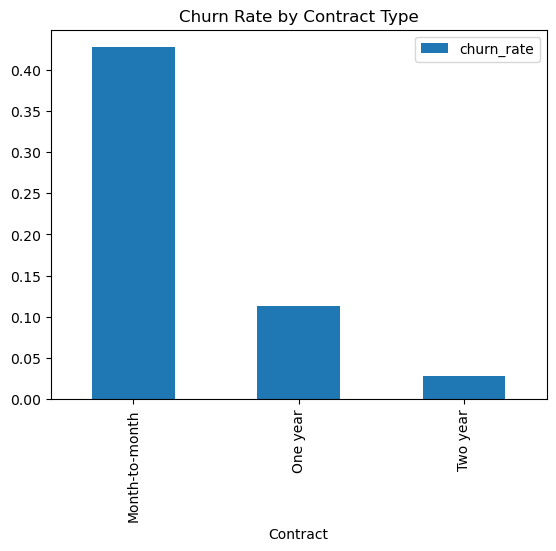

In [7]:
contract = pd.read_sql_query("""
SELECT
  Contract,
  AVG(CASE WHEN Churn = 'Yes' THEN 1.0 ELSE 0.0 END) AS churn_rate,
  COUNT(*) AS customers
FROM telecom_features
GROUP BY Contract
ORDER BY churn_rate DESC                         
 """, conn)

contract.plot(x='Contract', y='churn_rate', kind='bar')
plt.title("Churn Rate by Contract Type")
plt.show()

Month-to-month contracts show significantly higher churn compared to long-term contracts, indicating contract length is a key retention driver.

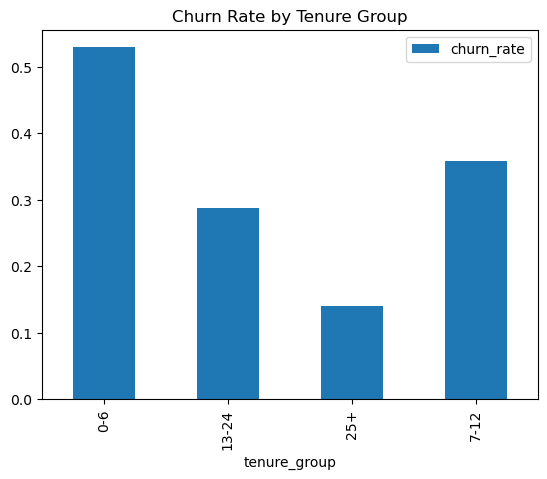

In [8]:
tenure = pd.read_sql_query("""
SELECT
  tenure_group,
  AVG(CASE WHEN Churn = 'Yes' THEN 1.0 ELSE 0.0 END) AS churn_rate,
  COUNT(*) AS customers
FROM telecom_features
GROUP BY tenure_group
ORDER BY tenure_group ASC                         
 """, conn)

tenure.plot(x='tenure_group', y='churn_rate', kind='bar')
plt.title("Churn Rate by Tenure Group")
plt.show()

Customers in early tenure groups show significantly higher churn compared to other tenure groups, suggesting that the first few months are critical for retention.

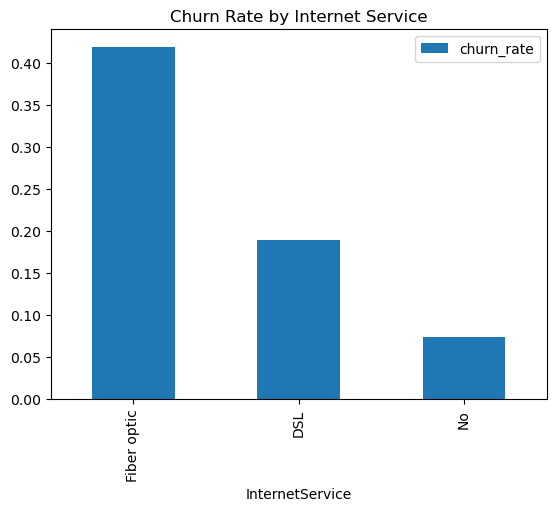

In [9]:
internet = pd.read_sql_query("""
SELECT
  InternetService,
  AVG(CASE WHEN Churn = 'Yes' THEN 1.0 ELSE 0.0 END) AS churn_rate,
  COUNT(*) AS customers
FROM telecom_features
GROUP BY InternetService
ORDER BY churn_rate DESC
 """, conn)

internet.plot(x='InternetService', y='churn_rate', kind='bar')
plt.title("Churn Rate by Internet Service")
plt.show()

Customers with fiber optic service tend to have significantly higher churn, suggesting potential issues with pricing or perceived value.

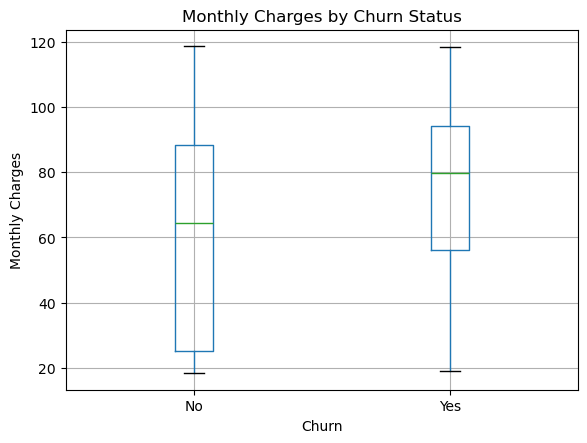

In [10]:
charges = pd.read_sql_query("""
SELECT Churn, MonthlyCharges
FROM telecom_features
""", conn)

charges.boxplot(column='MonthlyCharges', by='Churn')

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


Customers who churn tend to have higher monthly charges, indicating that pricing may influence churn behavior.

## 4. Segment Table
The table below segments customers by contract type and tenure, highlighting where churn and revenue risk are most concentrated.

In [11]:
segment = pd.read_sql_query("""
SELECT
  Contract,
  tenure_group,
  COUNT(*) AS customers,
  AVG(CASE WHEN Churn = 'Yes' THEN 1.0 ELSE 0.0 END) AS churn_rate,
  AVG(MonthlyCharges) AS avg_monthly_charges,
  SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END) AS revenue_at_risk_mrr
FROM telecom_features
GROUP BY Contract, tenure_group
ORDER BY revenue_at_risk_mrr DESC
LIMIT 10
""", conn)

segment

,Contract,tenure_group,customers,churn_rate,avg_monthly_charges,revenue_at_risk_mrr
0,Month-to-month,0-6,1413,0.552017,55.877141,49681.30
1,Month-to-month,25+,1144,0.308566,78.781906,30565.35
2,Month-to-month,13-24,737,0.377205,69.309566,21980.30
3,Month-to-month,7-12,581,0.419966,63.910671,18620.15
4,One year,25+,1152,0.118924,71.646354,12364.30
5,Two year,25+,1537,0.031230,63.756604,4165.30
6,One year,13-24,197,0.081218,44.878680,1101.35
7,One year,7-12,85,0.105882,39.672353,438.00
8,One year,0-6,39,0.102564,27.352564,214.80
9,Two year,0-6,29,0.000000,36.096552,0.00


- Month-to-month customers in their first 6 months represent the highest revenue exposure (~$49K MRR)
- Churn decreases significantly as contract length increases
- Long-tenure customers still show elevated churn when on month-to-month contracts

## 5. High Risk Profiles
The table below highlights the highest-risk customers segments based on churn rate, customer size, and revenue impact.

In [ ]:
high_risk = pd.read_sql_query("""
SELECT 
	Contract,
	tenure_group,
	InternetService,
	is_auto_pay,
	COUNT(*) AS customers,
	AVG(CASE WHEN Churn = 'Yes' THEN 1.0 ELSE 0.0 END) AS churn_rate,
	AVG(MonthlyCharges) AS avg_monthly_charges,
	SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END) AS revenue_at_risk_mrr
FROM telecom_features
GROUP BY Contract, tenure_group, InternetService,is_auto_pay
HAVING COUNT(*) >= 40
AND SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END) > 0
ORDER BY (churn_rate * avg_monthly_charges * customers) DESC
LIMIT 10                            
""", conn)

high_risk

,Contract,tenure_group,InternetService,is_auto_pay,customers,churn_rate,avg_monthly_charges,revenue_at_risk_mrr
0,Month-to-month,0-6,Fiber optic,0,536,0.731343,80.540578,31652.20
1,Month-to-month,25+,Fiber optic,0,462,0.435065,93.178030,18758.85
2,Month-to-month,13-24,Fiber optic,0,292,0.561644,88.246747,14611.00
3,Month-to-month,7-12,Fiber optic,0,218,0.614679,85.147706,11666.70
4,Month-to-month,0-6,DSL,0,401,0.513716,45.793766,9177.50
5,Month-to-month,25+,Fiber optic,1,325,0.316923,91.521846,9497.95
6,Month-to-month,0-6,Fiber optic,1,83,0.807229,81.193373,5497.95
7,One year,25+,Fiber optic,0,217,0.248848,99.231106,5427.20
8,Month-to-month,13-24,Fiber optic,1,133,0.383459,85.992857,4435.90
9,One year,25+,Fiber optic,1,292,0.150685,99.079110,4538.10


### Top Risk Profiles

- Month-to-month customers in early tenure with fiber optic services and no auto pay
- High paying fiber optic customers on month-to-month contracts
- Customers not enrolled in auto pay

## 6. Key Insights
- **Churn is the highest among early-tenure customers**

Customers in their first 6 months show the highest churn rates, indicating that early lifecycle engagement is critical.

- **Contract type is the strongest driver of churn**

Month-to-moth customers consistently exhibit significantly higher churn compared to long-term contracts.

- **Higher monthly charges are associated with increased churn.**

Customers with higher monthly charges are more likely to leave, which suggests pricing or perceived value issues.

- **Revenue risk concentrated in specific segments.**

A small number of high-risk segments contribute a significant portion of churn-related revenue loss.